# 1. Importando Bibliotecas

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 2. Analisando o dataset

In [51]:
df = pd.read_csv('data/telecom_customer_churn.csv', delimiter=',')

In [52]:
df.shape

(7043, 38)

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   str    
 1   Gender                             7043 non-null   str    
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   str    
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   str    
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   str    
 12  Pho

In [54]:
df.head(3)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices


In [55]:
df.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,25.420517,26.189958,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,14.200374,19.586585,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,13.050000,13.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,37.680000,30.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


## 2.1 Verificando nulos

In [56]:
df.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Married                                 0
Number of Dependents                    0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges     682
Multiple Lines                        682
Internet Service                        0
Internet Type                        1526
Avg Monthly GB Download              1526
Online Security                      1526
Online Backup                        1526
Device Protection Plan               1526
Premium Tech Support                 1526
Streaming TV                         1526
Streaming Movies                  

In [57]:
df[
    (df['Internet Type'].isnull()) & 
    (df['Avg Monthly GB Download'].isnull()) & 
    (df['Online Security'].isnull()) & 
    (df['Online Backup'].isnull()) & 
    (df['Device Protection Plan'].isnull()) & 
    (df['Premium Tech Support'].isnull()) &
    (df['Streaming TV'].isnull()) &
    (df['Streaming Movies'].isnull()) &
    (df['Streaming Music'].isnull()) &
    (df['Unlimited Data'].isnull())
   ]['Internet Service'].value_counts()

Internet Service
No    1526
Name: count, dtype: int64

Os nulos nas colunas acima são explicados por não terem serviço de internet

In [58]:
df[df['Churn Category'] == 'Churned'].isnull().sum().sum()

np.int64(0)

In [59]:
df[df['Churn Reason'] == 'Churned'].isnull().sum().sum()

np.int64(0)

Essas duas variáveis acima explicam a variável churn, sendo assim vou optar por tirar elas do dataset no tratamento de dados

In [60]:
df['Phone Service'].value_counts()

Phone Service
Yes    6361
No      682
Name: count, dtype: int64

In [61]:
df[df['Multiple Lines'].isnull()]['Phone Service'].value_counts()

Phone Service
No    682
Name: count, dtype: int64

In [62]:
df[df['Avg Monthly Long Distance Charges'].isnull()]['Phone Service'].value_counts()

Phone Service
No    682
Name: count, dtype: int64

Os nulos de 'Multiple Lines' e 'Avg Monthly Long Distance Charges' são os 'No' em Phone Service

In [63]:
df['Offer']

0           NaN
1           NaN
2       Offer E
3       Offer D
4           NaN
         ...   
7038    Offer D
7039    Offer D
7040    Offer E
7041    Offer A
7042        NaN
Name: Offer, Length: 7043, dtype: str

# 3. Tratamento de dados

In [64]:
df.drop(columns=['Customer ID', 'Churn Category', 'Churn Reason'], inplace=True)

In [65]:
df.duplicated().sum()

np.int64(0)

## 3.1 Tratando os nulos

In [66]:
df[['Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data']] = df[['Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data']].fillna('No Internet Service')
df['Avg Monthly GB Download'] = df['Avg Monthly GB Download'].fillna(0)

In [67]:
df[df['Phone Service'] == 'No'][['Avg Monthly Long Distance Charges', 'Multiple Lines']].value_counts()

Series([], Name: count, dtype: int64)

In [68]:
df['Multiple Lines'] = df['Multiple Lines'].fillna('No Phone Service')
df['Avg Monthly Long Distance Charges'] = df['Avg Monthly Long Distance Charges'].fillna(0)

In [69]:
df["Offer"] = df["Offer"].fillna("No Offer")

In [70]:
df.isnull().sum()

Gender                               0
Age                                  0
Married                              0
Number of Dependents                 0
City                                 0
Zip Code                             0
Latitude                             0
Longitude                            0
Number of Referrals                  0
Tenure in Months                     0
Offer                                0
Phone Service                        0
Avg Monthly Long Distance Charges    0
Multiple Lines                       0
Internet Service                     0
Internet Type                        0
Avg Monthly GB Download              0
Online Security                      0
Online Backup                        0
Device Protection Plan               0
Premium Tech Support                 0
Streaming TV                         0
Streaming Movies                     0
Streaming Music                      0
Unlimited Data                       0
Contract                 

# 4. Análise Exploratória de Dados (EDA)

In [71]:
import seaborn as sns
sns.set_style('whitegrid')

## 4.1 Distribuição da variável-alvo

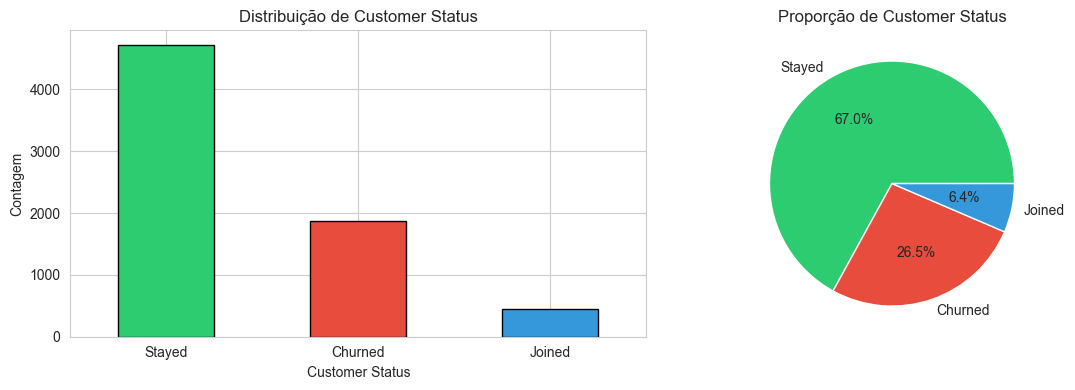

Customer Status
Stayed     4720
Churned    1869
Joined      454
Name: count, dtype: int64

Taxa de Churn: 26.5%


In [72]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Contagem
counts = df['Customer Status'].value_counts()
counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c', '#3498db'], edgecolor='black')
axes[0].set_title('Distribuição de Customer Status')
axes[0].set_ylabel('Contagem')
axes[0].tick_params(axis='x', rotation=0)

# Proporção
counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c', '#3498db'])
axes[1].set_ylabel('')
axes[1].set_title('Proporção de Customer Status')

plt.tight_layout()
plt.show()

print(counts)
print(f"\nTaxa de Churn: {counts.get('Churned', 0) / counts.sum() * 100:.1f}%")

## 4.2 Distribuição das variáveis numéricas por Customer Status

In [73]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Variáveis numéricas ({len(numeric_cols)}): {numeric_cols}")

Variáveis numéricas (15): ['Age', 'Number of Dependents', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals', 'Tenure in Months', 'Avg Monthly Long Distance Charges', 'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue']


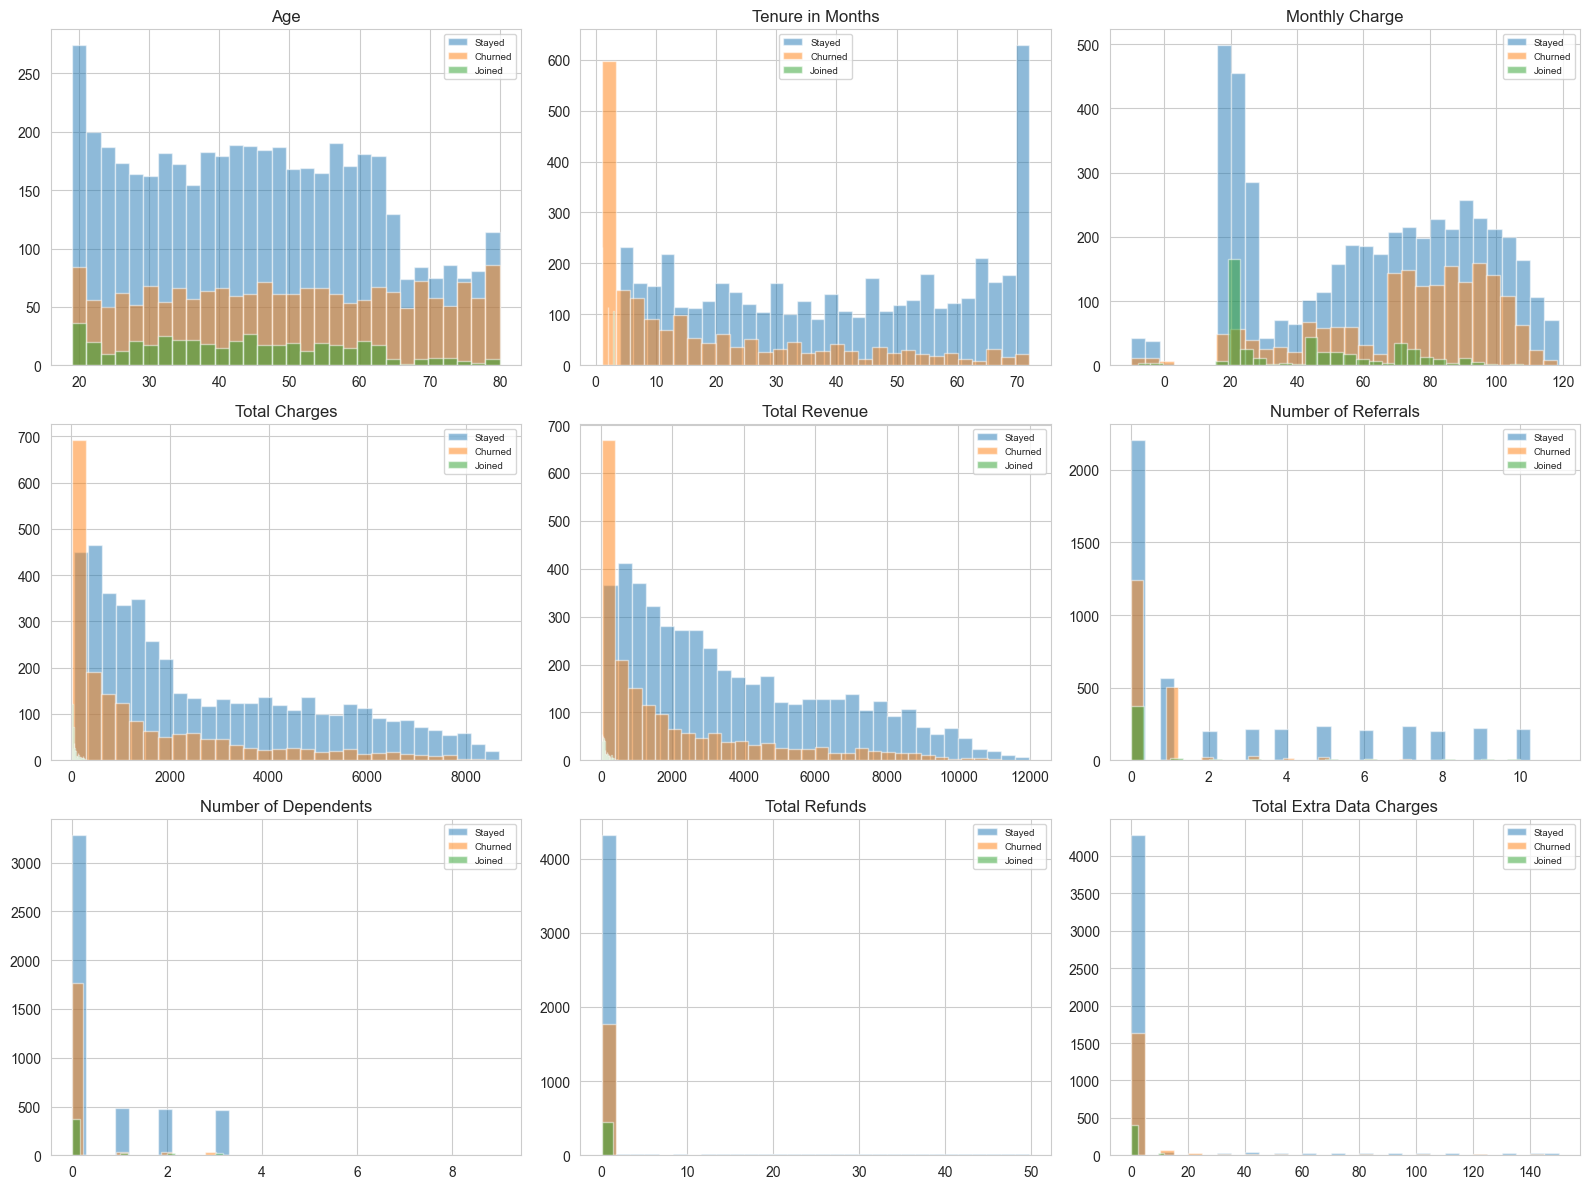

In [74]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

key_numeric = ['Age', 'Tenure in Months', 'Monthly Charge', 'Total Charges',
               'Total Revenue', 'Number of Referrals', 'Number of Dependents',
               'Total Refunds', 'Total Extra Data Charges']

for i, col in enumerate(key_numeric):
    for status in df['Customer Status'].unique():
        subset = df[df['Customer Status'] == status][col]
        axes[i].hist(subset, bins=30, alpha=0.5, label=status)
    axes[i].set_title(col)
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.show()

## 4.3 Correlação entre variáveis numéricas

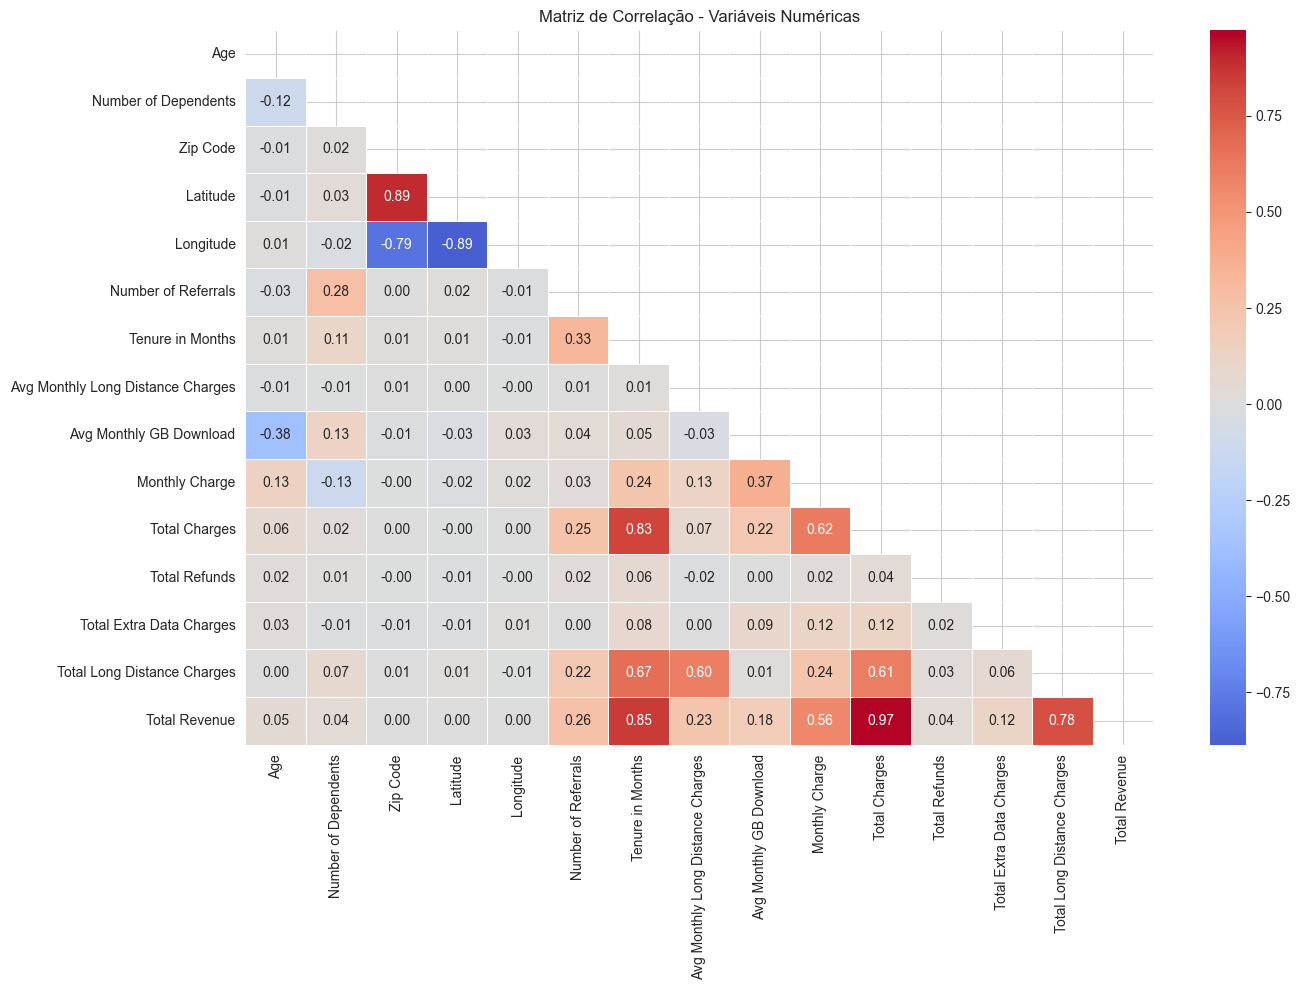

In [75]:
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matriz de Correlação - Variáveis Numéricas')
plt.tight_layout()
plt.show()

## 4.4 Variáveis categóricas vs Customer Status

In [76]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
cat_cols = [c for c in cat_cols if c != 'Customer Status']
print(f"Variáveis categóricas ({len(cat_cols)}): {cat_cols}")

Variáveis categóricas (19): ['Gender', 'Married', 'City', 'Offer', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method']


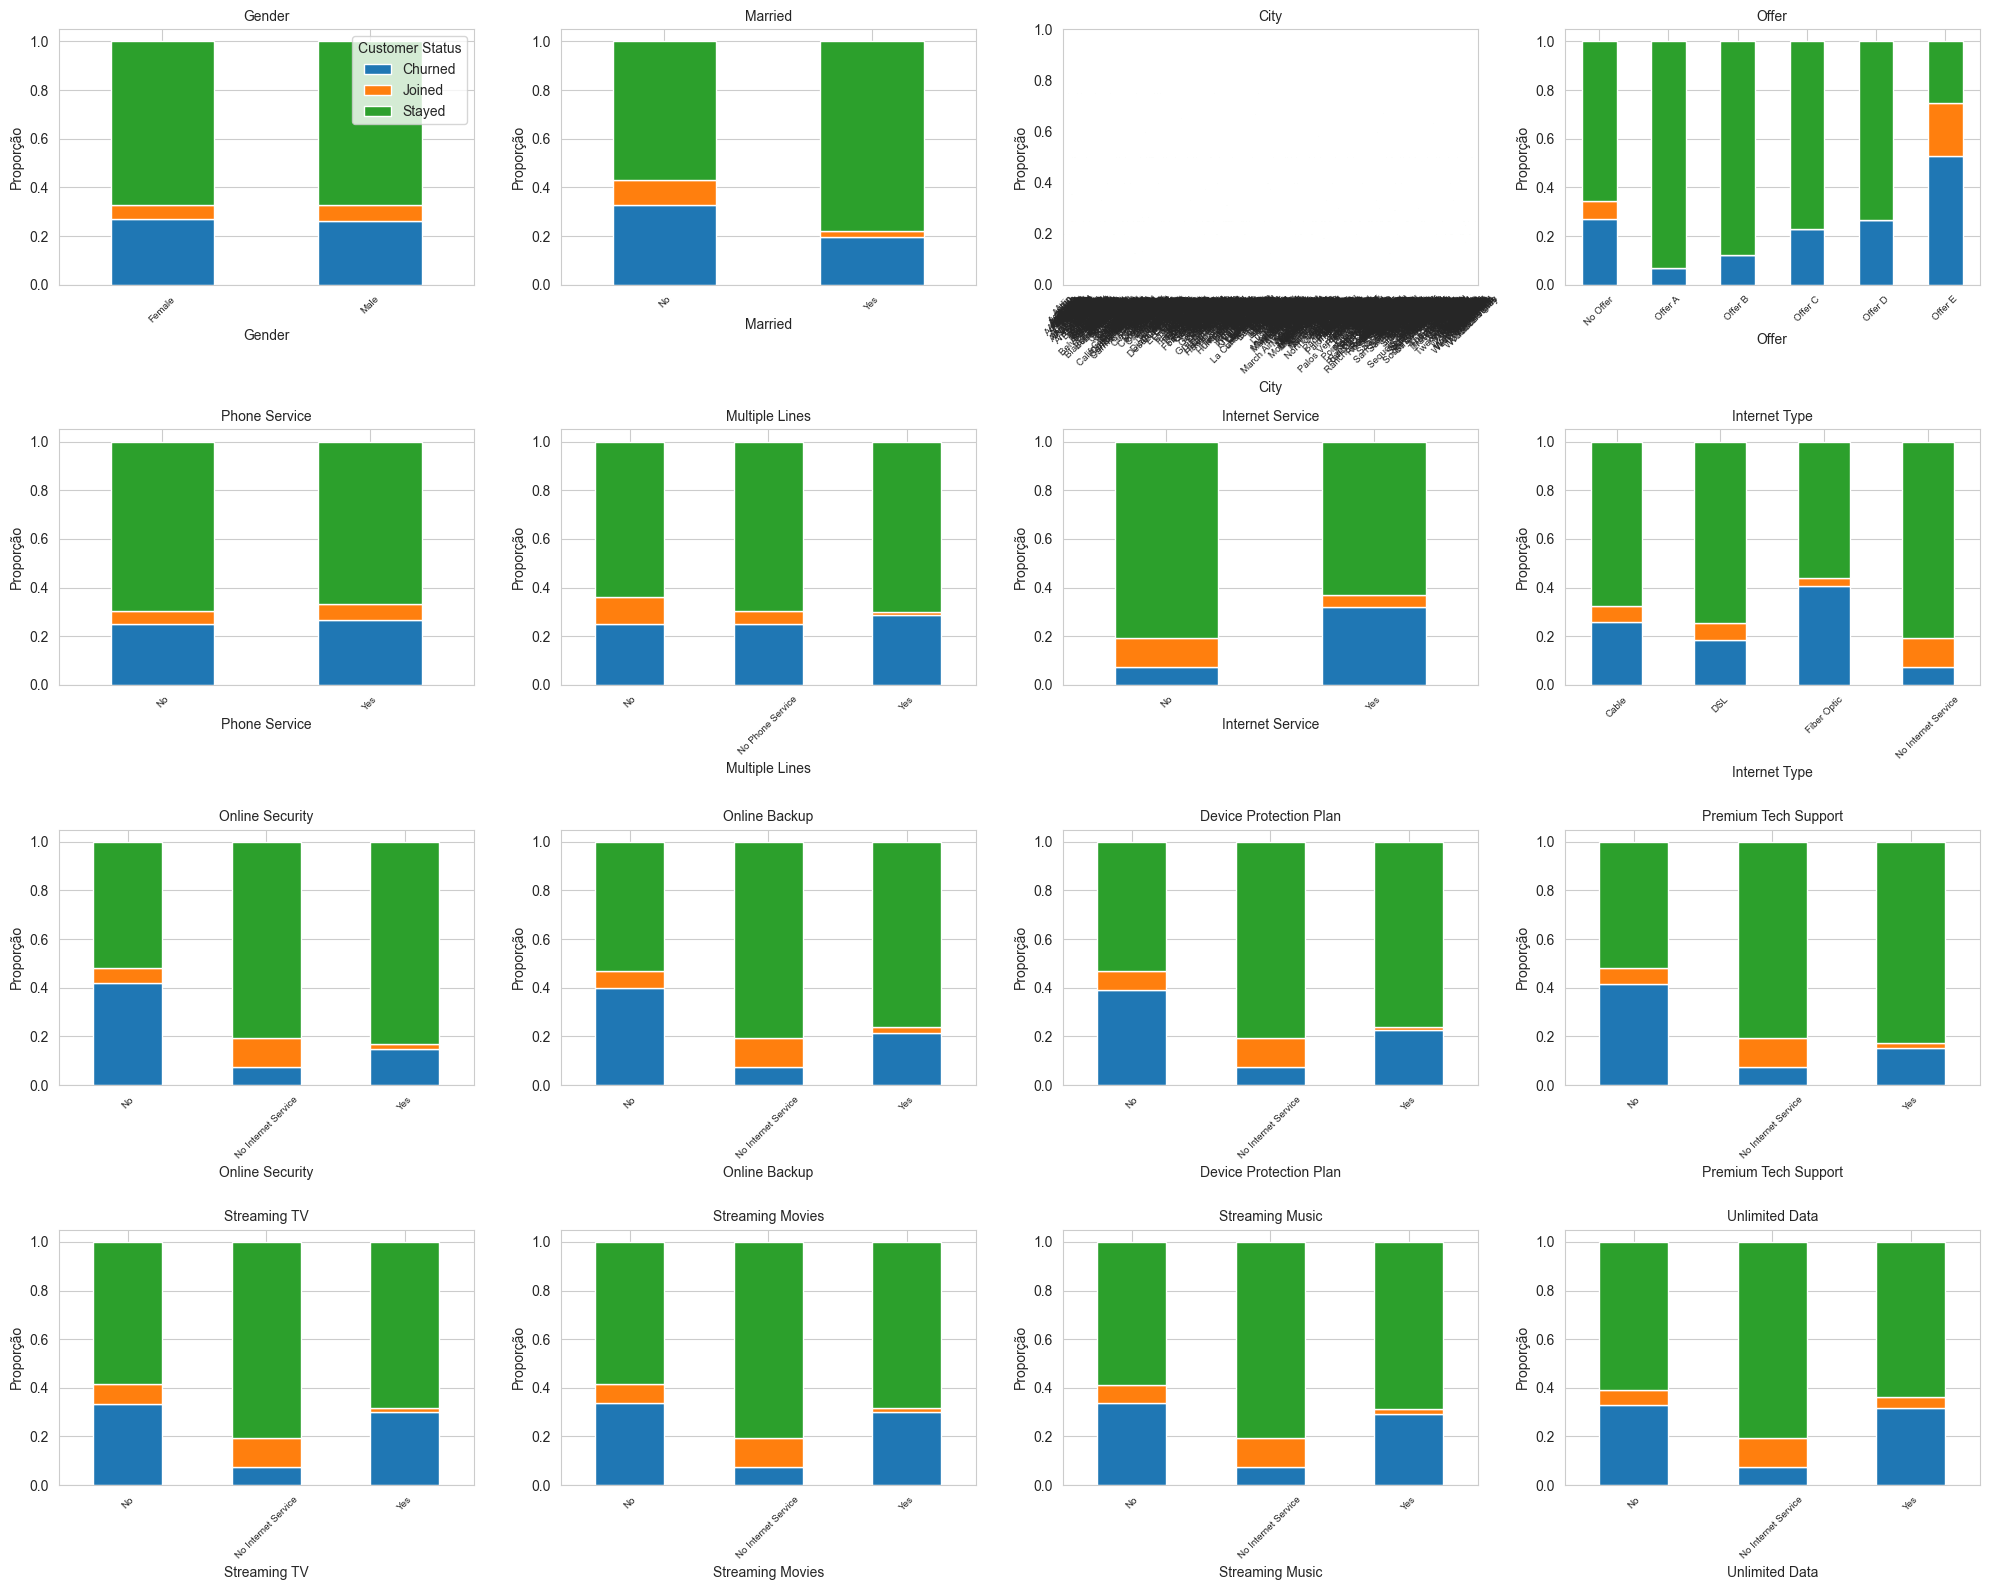

In [77]:
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    if i >= len(axes):
        break
    ct = pd.crosstab(df[col], df['Customer Status'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i], legend=(i == 0))
    axes[i].set_title(col, fontsize=10)
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)
    axes[i].set_ylabel('Proporção')

# Esconder axes vazios
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## 4.5 Insights do EDA

Observações principais:
- **Tenure in Months** é um forte indicador: clientes com poucos meses de contrato tendem a churnar mais.
- **Contract**: contratos mensais (Month-to-Month) apresentam taxa de churn muito superior aos anuais.
- **Total Charges e Total Revenue** são altamente correlacionados (~0.99) → manter apenas uma.
- **Latitude, Longitude, Zip Code, City**: variáveis geográficas com alta cardinalidade e baixo poder preditivo para árvores de decisão → serão removidas.
- **Phone Service** é redundante com Multiple Lines (quem não tem Phone Service tem Multiple Lines = "No Phone Service").
- **Internet Service** é redundante com Internet Type pelo mesmo motivo.

# 5. Feature Engineering

## 5.1 Removendo colunas irrelevantes ou redundantes

In [78]:
cols_to_drop = [
    'City',                # Alta cardinalidade (~1100 cidades)
    'Zip Code',            # Alta cardinalidade
    'Latitude',            # Geolocalização não útil para árvore
    'Longitude',           # Geolocalização não útil para árvore
    'Total Revenue',       # Altamente correlacionado com Total Charges (~0.99)
    'Phone Service',       # Redundante com Multiple Lines
    'Internet Service',    # Redundante com Internet Type
]

df.drop(columns=cols_to_drop, inplace=True)
print(f"Colunas restantes ({df.shape[1]}): {df.columns.tolist()}")

Colunas restantes (28): ['Gender', 'Age', 'Married', 'Number of Dependents', 'Number of Referrals', 'Tenure in Months', 'Offer', 'Avg Monthly Long Distance Charges', 'Multiple Lines', 'Internet Type', 'Avg Monthly GB Download', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 'Customer Status']


## 5.2 Corrigindo colunas com tipos mistos

As colunas `Avg Monthly Long Distance Charges` e `Avg Monthly GB Download` receberam strings ("No Phone Service" / "No Internet Service") no tratamento de nulos. Vamos converter para numérico (0.0).

In [79]:
df['Avg Monthly Long Distance Charges'] = pd.to_numeric(df['Avg Monthly Long Distance Charges'], errors='coerce').fillna(0.0)
df['Avg Monthly GB Download'] = pd.to_numeric(df['Avg Monthly GB Download'], errors='coerce').fillna(0.0)

print(df[['Avg Monthly Long Distance Charges', 'Avg Monthly GB Download']].dtypes)
print(df[['Avg Monthly Long Distance Charges', 'Avg Monthly GB Download']].describe())

Avg Monthly Long Distance Charges    float64
Avg Monthly GB Download              float64
dtype: object
       Avg Monthly Long Distance Charges  Avg Monthly GB Download
count                        7043.000000              7043.000000
mean                           22.958954                20.515405
std                            15.448113                20.418940
min                             0.000000                 0.000000
25%                             9.210000                 3.000000
50%                            22.890000                17.000000
75%                            36.395000                27.000000
max                            49.990000                85.000000


## 5.3 Encoding de variáveis categóricas

Utilizaremos `LabelEncoder` para converter variáveis categóricas em numéricas. O scikit-learn `DecisionTreeClassifier` exige features numéricas.

In [80]:
from sklearn.preprocessing import LabelEncoder

# Separar target antes do encoding
target = df['Customer Status']
features_df = df.drop(columns=['Customer Status'])

# Identificar colunas categóricas
cat_cols_to_encode = features_df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f"Colunas a codificar ({len(cat_cols_to_encode)}): {cat_cols_to_encode}")

# Aplicar LabelEncoder e guardar os mapeamentos
label_encoders = {}
for col in cat_cols_to_encode:
    le = LabelEncoder()
    features_df[col] = le.fit_transform(features_df[col].astype(str))
    label_encoders[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Encoder para o target
le_target = LabelEncoder()
target_encoded = le_target.fit_transform(target)
print(f"\nTarget encoding: {dict(zip(le_target.classes_, le_target.transform(le_target.classes_)))}")

Colunas a codificar (16): ['Gender', 'Married', 'Offer', 'Multiple Lines', 'Internet Type', 'Online Security', 'Online Backup', 'Device Protection Plan', 'Premium Tech Support', 'Streaming TV', 'Streaming Movies', 'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing', 'Payment Method']
  Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
  Married: {'No': np.int64(0), 'Yes': np.int64(1)}
  Offer: {'No Offer': np.int64(0), 'Offer A': np.int64(1), 'Offer B': np.int64(2), 'Offer C': np.int64(3), 'Offer D': np.int64(4), 'Offer E': np.int64(5)}
  Multiple Lines: {'No': np.int64(0), 'No Phone Service': np.int64(1), 'Yes': np.int64(2)}
  Internet Type: {'Cable': np.int64(0), 'DSL': np.int64(1), 'Fiber Optic': np.int64(2), 'No Internet Service': np.int64(3)}
  Online Security: {'No': np.int64(0), 'No Internet Service': np.int64(1), 'Yes': np.int64(2)}
  Online Backup: {'No': np.int64(0), 'No Internet Service': np.int64(1), 'Yes': np.int64(2)}
  Device Protection Plan: {'No': n

## 5.4 Seleção de features

Vamos analisar a correlação das features com o target para identificar as mais relevantes.

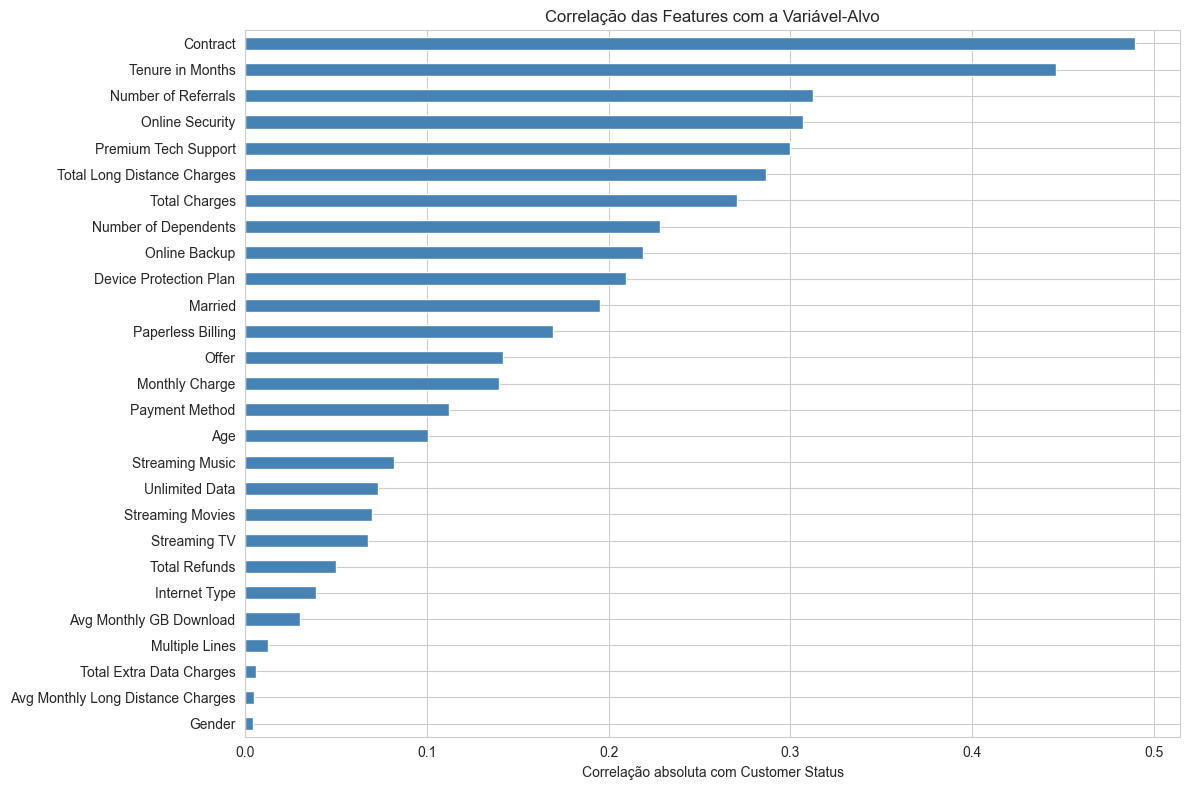

Top 10 features:
Contract                       0.490011
Tenure in Months               0.446411
Number of Referrals            0.312558
Online Security                0.306742
Premium Tech Support           0.300087
Total Long Distance Charges    0.286554
Total Charges                  0.270864
Number of Dependents           0.228119
Online Backup                  0.218868
Device Protection Plan         0.209308
Name: target, dtype: float64


In [81]:
# Correlação com o target
features_df['target'] = target_encoded
corr_with_target = features_df.corr()['target'].drop('target').abs().sort_values(ascending=False)
features_df.drop(columns=['target'], inplace=True)

plt.figure(figsize=(12, 8))
corr_with_target.plot(kind='barh', color='steelblue')
plt.xlabel('Correlação absoluta com Customer Status')
plt.title('Correlação das Features com a Variável-Alvo')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(corr_with_target.head(10))

In [82]:
# Selecionar features com correlação > 0.05 com o target
threshold = 0.05
selected_features = corr_with_target[corr_with_target > threshold].index.tolist()
dropped_features = corr_with_target[corr_with_target <= threshold].index.tolist()

print(f"Features selecionadas ({len(selected_features)}): {selected_features}")
print(f"Features removidas ({len(dropped_features)}): {dropped_features}")

X = features_df[selected_features]
y = target_encoded

print(f"\nShape final: X={X.shape}, y={y.shape}")

Features selecionadas (20): ['Contract', 'Tenure in Months', 'Number of Referrals', 'Online Security', 'Premium Tech Support', 'Total Long Distance Charges', 'Total Charges', 'Number of Dependents', 'Online Backup', 'Device Protection Plan', 'Married', 'Paperless Billing', 'Offer', 'Monthly Charge', 'Payment Method', 'Age', 'Streaming Music', 'Unlimited Data', 'Streaming Movies', 'Streaming TV']
Features removidas (7): ['Total Refunds', 'Internet Type', 'Avg Monthly GB Download', 'Multiple Lines', 'Total Extra Data Charges', 'Avg Monthly Long Distance Charges', 'Gender']

Shape final: X=(7043, 20), y=(7043,)


## 5.5 Divisão treino/teste

In [83]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"\nDistribuição do target no treino:")
for cls, name in zip(*np.unique(y_train, return_counts=True)):
    print(f"  {le_target.inverse_transform([cls])[0]}: {name} ({name/len(y_train)*100:.1f}%)")

Treino: 5634 amostras
Teste:  1409 amostras

Distribuição do target no treino:
  Churned: 1495 (26.5%)
  Joined: 363 (6.4%)
  Stayed: 3776 (67.0%)


# 6. Árvore de Decisão — ID3 (Entropia / Ganho de Informação, sem poda)

O algoritmo **ID3** utiliza a **entropia** e o **ganho de informação** como critério de partição. A cada nó, o atributo que maximiza o ganho de informação (maior redução de entropia) é escolhido para a divisão.

**Conceitos:**
- **Entropia**: $H(S) = -\sum_{i=1}^{c} p_i \log_2(p_i)$, onde $p_i$ é a proporção da classe $i$ no conjunto $S$. Mede a impureza/desordem dos dados.
- **Ganho de Informação**: $IG(S, A) = H(S) - \sum_{v \in valores(A)} \frac{|S_v|}{|S|} H(S_v)$. Quanto maior o ganho, melhor o atributo separa as classes.
- **Partições recursivas**: o processo se repete em cada subconjunto até que todos os exemplos pertençam à mesma classe ou não haja mais atributos.
- **Condição de parada (sem poda)**: a árvore cresce até folhas puras ou até esgotar os atributos.

Nesta seção, simulamos o ID3 com `criterion="entropy"` sem restrições de profundidade ou poda.

In [84]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# ID3: Entropia, sem poda
tree_id3 = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)
tree_id3.fit(X_train, y_train)

y_pred_id3 = tree_id3.predict(X_test)

print(f"Profundidade da árvore: {tree_id3.get_depth()}")
print(f"Número de folhas: {tree_id3.get_n_leaves()}")
print(f"\nAcurácia no treino: {tree_id3.score(X_train, y_train):.4f}")
print(f"Acurácia no teste:  {accuracy_score(y_test, y_pred_id3):.4f}")
print(f"\n{classification_report(y_test, y_pred_id3, target_names=le_target.classes_)}")

Profundidade da árvore: 27
Número de folhas: 747

Acurácia no treino: 1.0000
Acurácia no teste:  0.7949

              precision    recall  f1-score   support

     Churned       0.61      0.64      0.62       374
      Joined       0.64      0.69      0.67        91
      Stayed       0.89      0.87      0.88       944

    accuracy                           0.79      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.80      0.79      0.80      1409



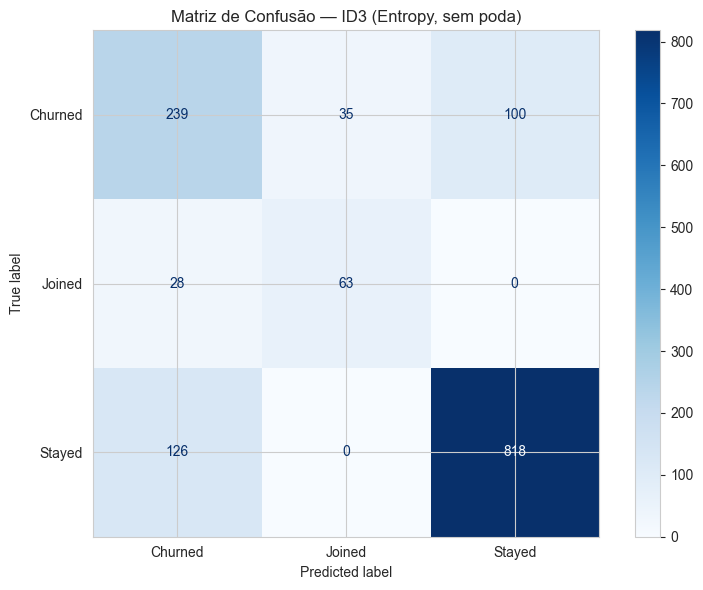

In [85]:
# Matriz de confusão
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_id3,
    display_labels=le_target.classes_,
    cmap='Blues', ax=ax
)
ax.set_title('Matriz de Confusão — ID3 (Entropy, sem poda)')
plt.tight_layout()
plt.show()

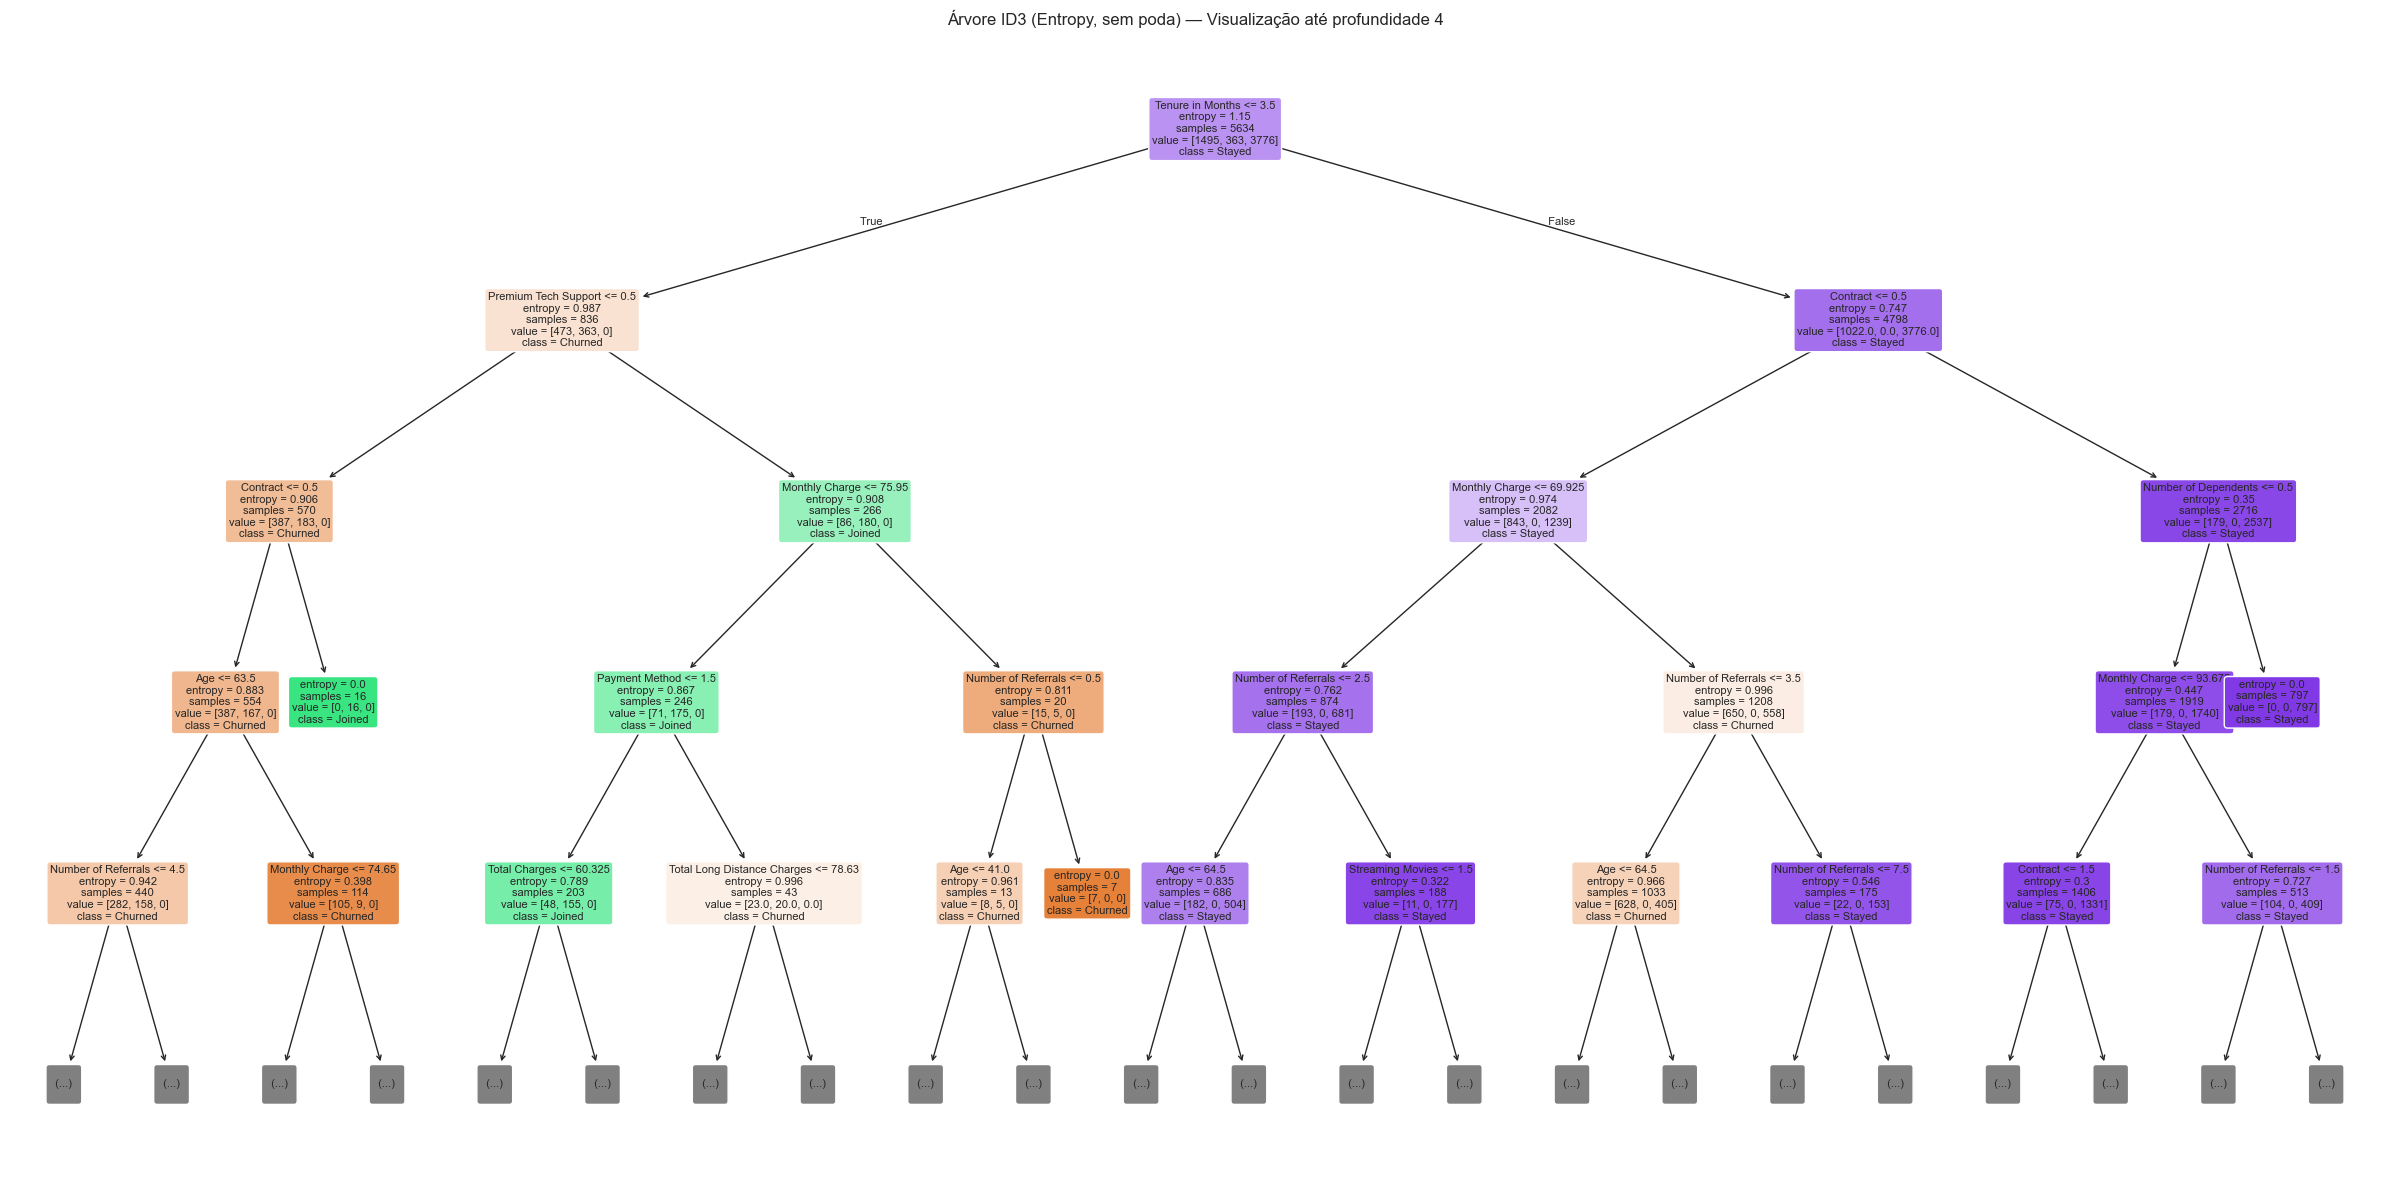

In [86]:
# Visualização da árvore (limitada a profundidade 4 para legibilidade)
plt.figure(figsize=(24, 12))
plot_tree(
    tree_id3,
    max_depth=4,
    feature_names=selected_features,
    class_names=le_target.classes_,
    filled=True,
    rounded=True,
    fontsize=8,
    impurity=True
)
plt.title('Árvore ID3 (Entropy, sem poda) — Visualização até profundidade 4')
plt.tight_layout()
plt.show()

# 7. Árvore de Decisão — C4.5 (Entropia + Poda)

O **C4.5** é uma evolução do ID3 com melhorias importantes:
- **Tratamento de atributos contínuos**: o algoritmo avalia todos os limiares possíveis para dividir um atributo numérico, escolhendo o ponto de corte que maximiza o ganho de informação.
- **Poda pós-construção**: após construir a árvore completa, ramos que não contribuem significativamente para a acurácia são removidos, reduzindo overfitting.

No scikit-learn, simulamos o C4.5 usando `criterion="entropy"` com **Cost-Complexity Pruning** (`ccp_alpha`). O parâmetro `ccp_alpha` controla a intensidade da poda: quanto maior o alpha, mais agressiva a poda.

## 7.1 Encontrando o ccp_alpha ótimo via Pruning Path

In [87]:
# Calcular o caminho de poda
path = tree_id3.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

print(f"Número de alphas candidatos: {len(ccp_alphas)}")
print(f"Range de alpha: [{ccp_alphas.min():.6f}, {ccp_alphas.max():.6f}]")

Número de alphas candidatos: 389
Range de alpha: [0.000000, 0.366857]


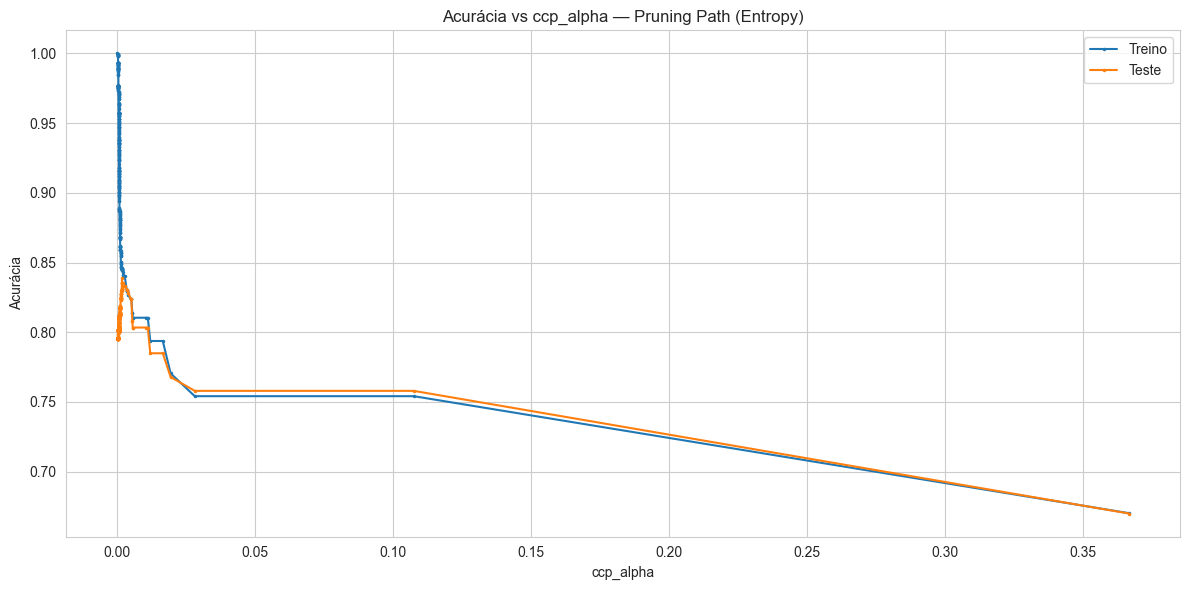

In [88]:
# Treinar árvores para cada alpha e medir acurácia
train_scores = []
test_scores = []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(criterion='entropy', ccp_alpha=alpha, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

# Gráfico alpha vs acurácia
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(ccp_alphas, train_scores, marker='.', label='Treino', markersize=3)
ax.plot(ccp_alphas, test_scores, marker='.', label='Teste', markersize=3)
ax.set_xlabel('ccp_alpha')
ax.set_ylabel('Acurácia')
ax.set_title('Acurácia vs ccp_alpha — Pruning Path (Entropy)')
ax.legend()
plt.tight_layout()
plt.show()

## 7.2 Seleção do alpha ótimo via Validação Cruzada

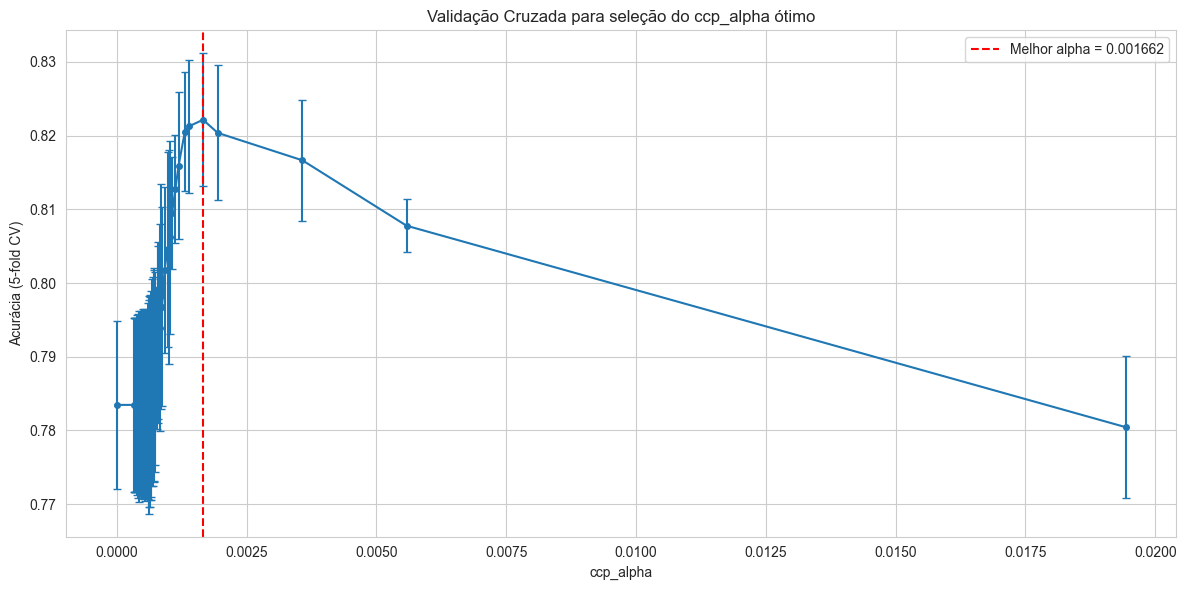

Melhor alpha: 0.001662
Acurácia CV média: 0.8222 (+/- 0.0090)


In [89]:
from sklearn.model_selection import cross_val_score

# Testar alphas em um range razoável (pegar ~50 valores espaçados)
alpha_candidates = ccp_alphas[::max(1, len(ccp_alphas) // 50)]

cv_means = []
cv_stds = []

for alpha in alpha_candidates:
    clf = DecisionTreeClassifier(criterion='entropy', ccp_alpha=alpha, random_state=42)
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

cv_means = np.array(cv_means)
cv_stds = np.array(cv_stds)

best_idx = np.argmax(cv_means)
best_alpha = alpha_candidates[best_idx]

plt.figure(figsize=(12, 6))
plt.errorbar(alpha_candidates, cv_means, yerr=cv_stds, marker='o', markersize=4, capsize=3)
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Melhor alpha = {best_alpha:.6f}')
plt.xlabel('ccp_alpha')
plt.ylabel('Acurácia (5-fold CV)')
plt.title('Validação Cruzada para seleção do ccp_alpha ótimo')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Melhor alpha: {best_alpha:.6f}")
print(f"Acurácia CV média: {cv_means[best_idx]:.4f} (+/- {cv_stds[best_idx]:.4f})")

## 7.3 Árvore C4.5 podada (alpha ótimo)

In [90]:
# C4.5: Entropia + poda
tree_c45 = DecisionTreeClassifier(
    criterion='entropy',
    ccp_alpha=best_alpha,
    random_state=42
)
tree_c45.fit(X_train, y_train)

y_pred_c45 = tree_c45.predict(X_test)

print(f"Profundidade da árvore: {tree_c45.get_depth()}")
print(f"Número de folhas: {tree_c45.get_n_leaves()}")
print(f"\nAcurácia no treino: {tree_c45.score(X_train, y_train):.4f}")
print(f"Acurácia no teste:  {accuracy_score(y_test, y_pred_c45):.4f}")
print(f"\n{classification_report(y_test, y_pred_c45, target_names=le_target.classes_)}")

Profundidade da árvore: 9
Número de folhas: 38

Acurácia no treino: 0.8454
Acurácia no teste:  0.8304

              precision    recall  f1-score   support

     Churned       0.69      0.65      0.67       374
      Joined       0.69      0.57      0.63        91
      Stayed       0.89      0.93      0.91       944

    accuracy                           0.83      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.82      0.83      0.83      1409



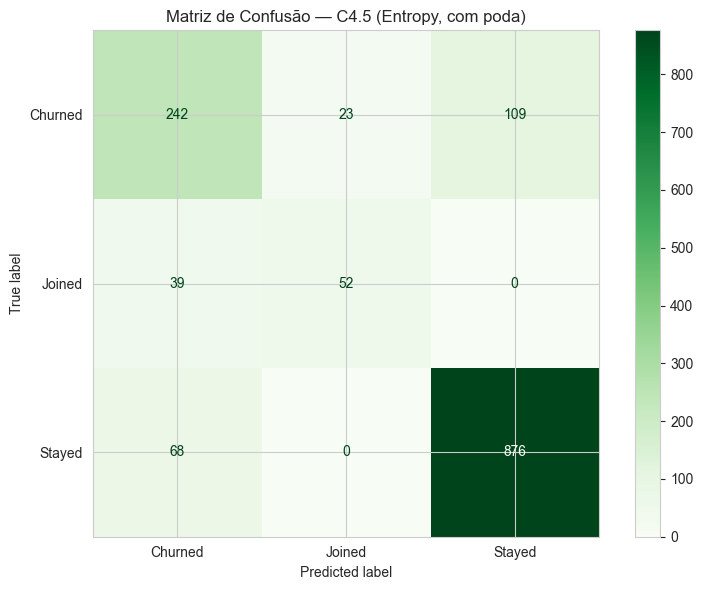

In [91]:
# Matriz de confusão
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_c45,
    display_labels=le_target.classes_,
    cmap='Greens', ax=ax
)
ax.set_title('Matriz de Confusão — C4.5 (Entropy, com poda)')
plt.tight_layout()
plt.show()

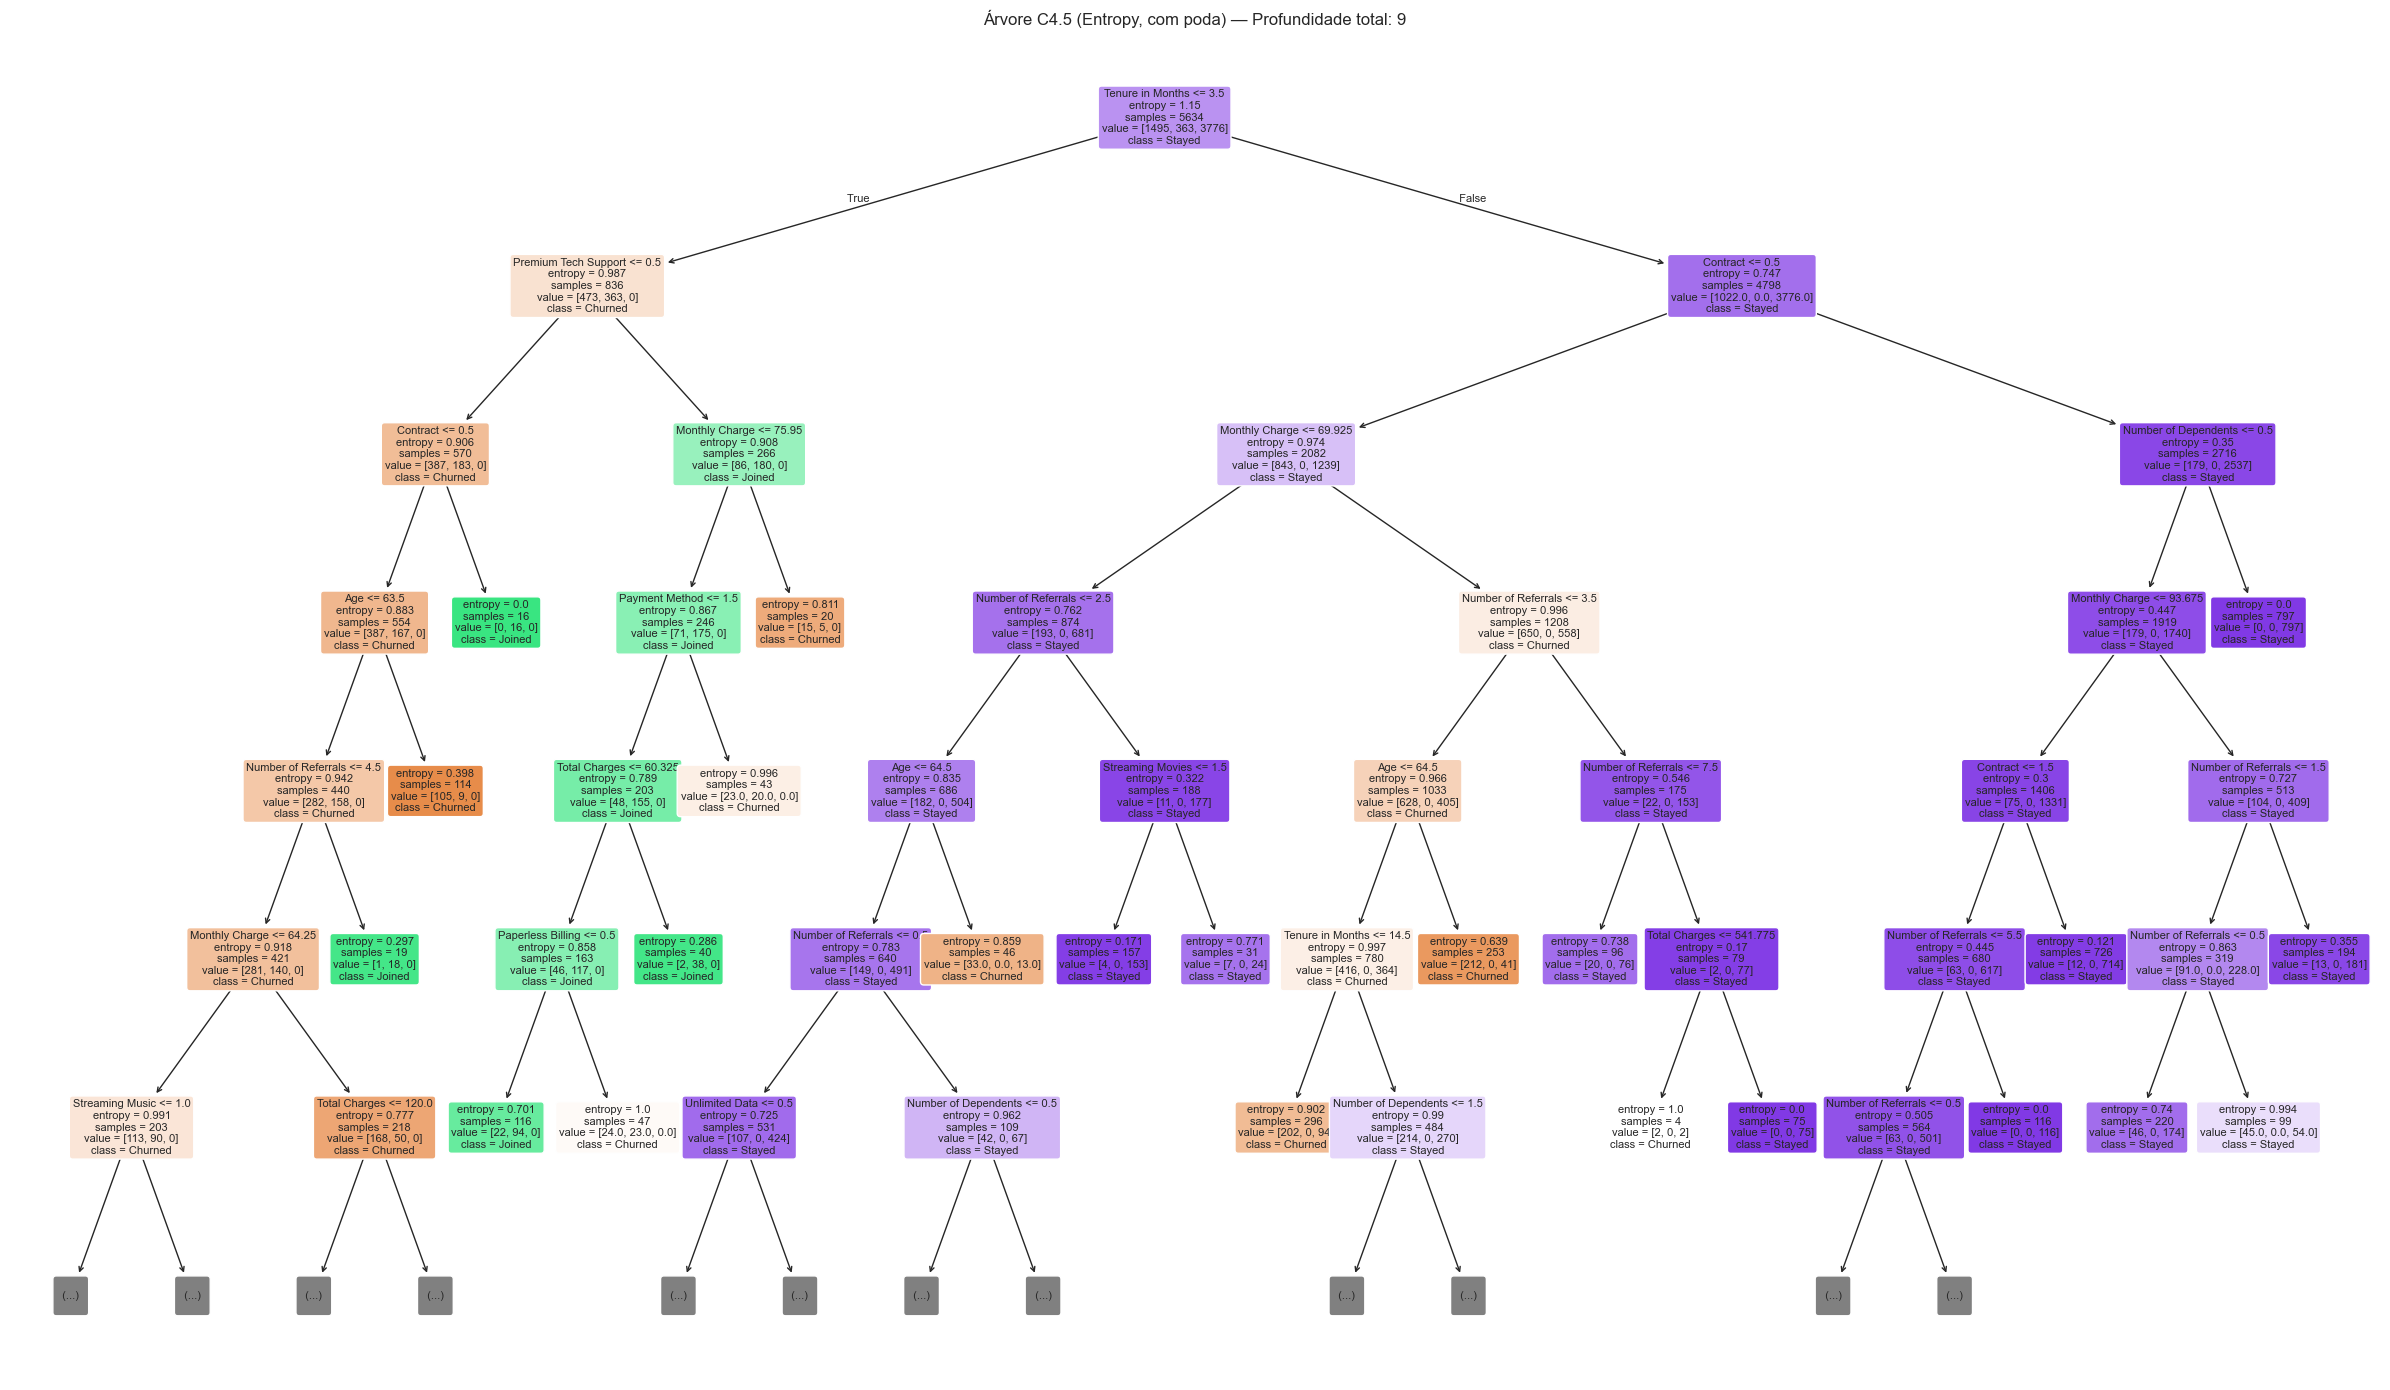

In [92]:
# Visualização da árvore podada
depth_viz = min(tree_c45.get_depth(), 6)
plt.figure(figsize=(24, 14))
plot_tree(
    tree_c45,
    max_depth=depth_viz,
    feature_names=selected_features,
    class_names=le_target.classes_,
    filled=True,
    rounded=True,
    fontsize=8,
    impurity=True
)
plt.title(f'Árvore C4.5 (Entropy, com poda) — Profundidade total: {tree_c45.get_depth()}')
plt.tight_layout()
plt.show()

# 8. Comparação entre configurações

A lauda exige comparação entre **pelo menos duas configurações**. Vamos comparar as duas variantes desenvolvidas:

| Config | Critério | Poda | Simula |
|--------|----------|------|--------|
| A | Entropy | Sem | ID3 |
| B | Entropy | Com (ccp_alpha ótimo) | C4.5 |


In [93]:
# Treinar as 2 configurações
configs = {}

# A - ID3 (já treinado)
configs['ID3 (Entropy, sem poda)'] = tree_id3

# B - C4.5 (já treinado)
configs['C4.5 (Entropy, com poda)'] = tree_c45


In [94]:
# Tabela comparativa
from sklearn.metrics import f1_score

results = []
for name, model in configs.items():
    y_pred = model.predict(X_test)
    results.append({
        'Configuração': name,
        'Acurácia Treino': model.score(X_train, y_train),
        'Acurácia Teste': accuracy_score(y_test, y_pred),
        'F1 Macro': f1_score(y_test, y_pred, average='macro'),
        'Profundidade': model.get_depth(),
        'N° Folhas': model.get_n_leaves()
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

            Configuração  Acurácia Treino  Acurácia Teste  F1 Macro  Profundidade  N° Folhas
 ID3 (Entropy, sem poda)         1.000000        0.794890  0.722833            27        747
C4.5 (Entropy, com poda)         0.845403        0.830376  0.734727             9         38


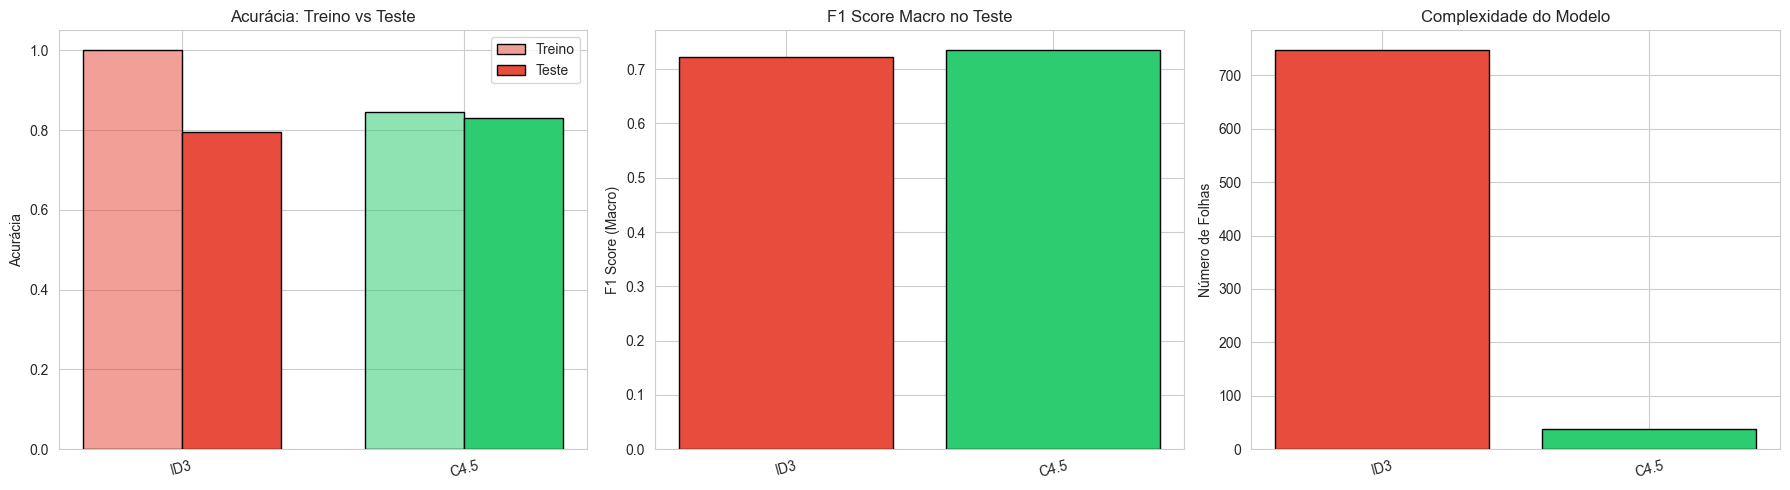

In [95]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

names = results_df['Configuração']
x = range(len(names))
colors = ['#e74c3c', '#2ecc71']

# Acurácia
axes[0].bar(x, results_df['Acurácia Treino'], width=0.35, label='Treino', color=[c + '88' for c in colors], edgecolor='black')
axes[0].bar([i + 0.35 for i in x], results_df['Acurácia Teste'], width=0.35, label='Teste', color=colors, edgecolor='black')
axes[0].set_ylabel('Acurácia')
axes[0].set_title('Acurácia: Treino vs Teste')
axes[0].set_xticks([i + 0.175 for i in x])
axes[0].set_xticklabels([n.split('(')[0].strip() for n in names], rotation=15)
axes[0].legend()

# F1 Macro
axes[1].bar(x, results_df['F1 Macro'], color=colors, edgecolor='black')
axes[1].set_ylabel('F1 Score (Macro)')
axes[1].set_title('F1 Score Macro no Teste')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels([n.split('(')[0].strip() for n in names], rotation=15)

# Complexidade
axes[2].bar(x, results_df['N° Folhas'], color=colors, edgecolor='black')
axes[2].set_ylabel('Número de Folhas')
axes[2].set_title('Complexidade do Modelo')
axes[2].set_xticks(list(x))
axes[2].set_xticklabels([n.split('(')[0].strip() for n in names], rotation=15)

plt.tight_layout()
plt.show()


## 8.1 Curvas de Validação: Acurácia por Profundidade Máxima

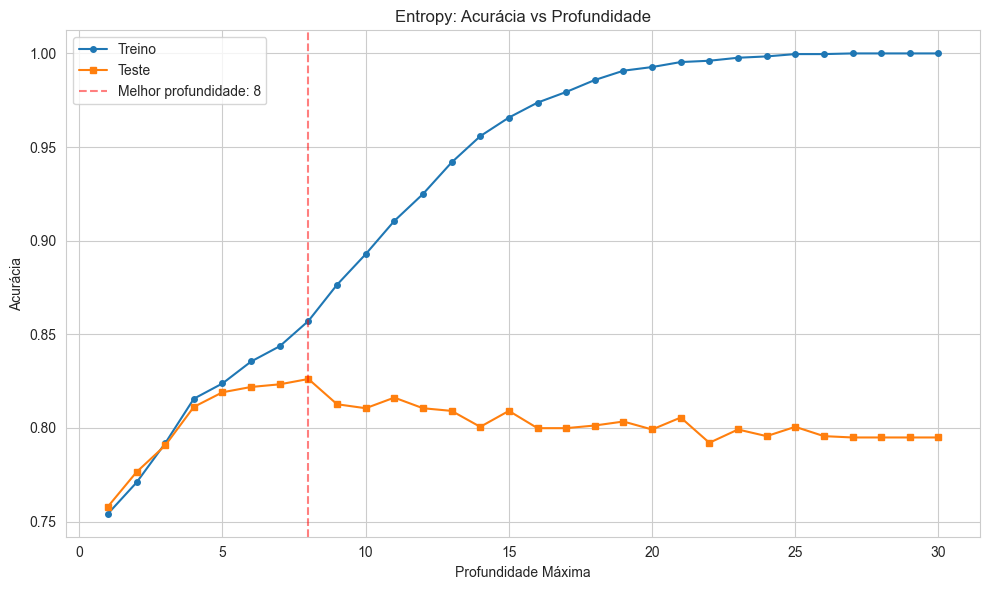

Melhor profundidade (Entropy): 8 — Acurácia teste: 0.8261


In [96]:
# Curva de validação por profundidade (criterion='entropy')
depths = range(1, 31)
train_acc = []
test_acc = []

for d in depths:
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_acc.append(clf.score(X_train, y_train))
    test_acc.append(clf.score(X_test, y_test))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(depths, train_acc, 'o-', label='Treino', markersize=4)
ax.plot(depths, test_acc, 's-', label='Teste', markersize=4)
ax.set_xlabel('Profundidade Máxima')
ax.set_ylabel('Acurácia')
ax.set_title('Entropy: Acurácia vs Profundidade')
best_depth = int(np.argmax(test_acc)) + 1
ax.axvline(x=best_depth, color='red', linestyle='--', alpha=0.5, label=f'Melhor profundidade: {best_depth}')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Melhor profundidade (Entropy): {best_depth} — Acurácia teste: {max(test_acc):.4f}")


# 9. Discussão: Overfitting, Poda e Validação

## O que é overfitting?
Overfitting ocorre quando o modelo se ajusta excessivamente aos dados de treino, capturando ruído e padrões específicos que não se generalizam para dados novos. Uma árvore de decisão sem restrições cresce até que cada folha seja pura (entropia = 0), o que tipicamente resulta em:
- **Acurácia de treino ~100%**
- **Acurácia de teste significativamente menor**

Isso ficou evidente na Seção 6 (ID3 sem poda) versus a Seção 7 (C4.5 com poda).

## Papel da poda
A **poda** (pruning) é a principal técnica para controlar overfitting em árvores de decisão:
- **Pré-poda**: limitar a árvore durante a construção (`max_depth`, `min_samples_split`, `min_samples_leaf`)
- **Pós-poda (Cost-Complexity Pruning)**: construir a árvore completa e depois remover ramos que não contribuem para a generalização. O parâmetro `ccp_alpha` penaliza a complexidade — quanto maior o alpha, mais a árvore é simplificada.

Na Seção 7, usamos o **pruning path** para visualizar como o alpha afeta treino e teste, e **validação cruzada 5-fold** para escolher o alpha ótimo sem contaminar o conjunto de teste.

## Papel da validação
A **validação cruzada** evita que a escolha de hiperparâmetros (como `ccp_alpha` ou `max_depth`) seja enviesada pelo conjunto de teste. Ao dividir o treino em 5 folds, estimamos o desempenho de cada configuração de forma robusta, garantindo que o modelo final generaliza melhor.

## Curvas de validação
A curva de profundidade (Seção 8.1) mostra visualmente o tradeoff viés-variância:
- **Profundidades baixas**: alta entropia, modelo subajustado (underfitting)
- **Profundidades altas**: baixa entropia no treino, mas acurácia no teste estagna ou cai (overfitting)
- **Profundidade ótima**: ponto onde a acurácia de teste é máxima


# 10. Interpretação do Modelo

## 10.1 Features mais importantes

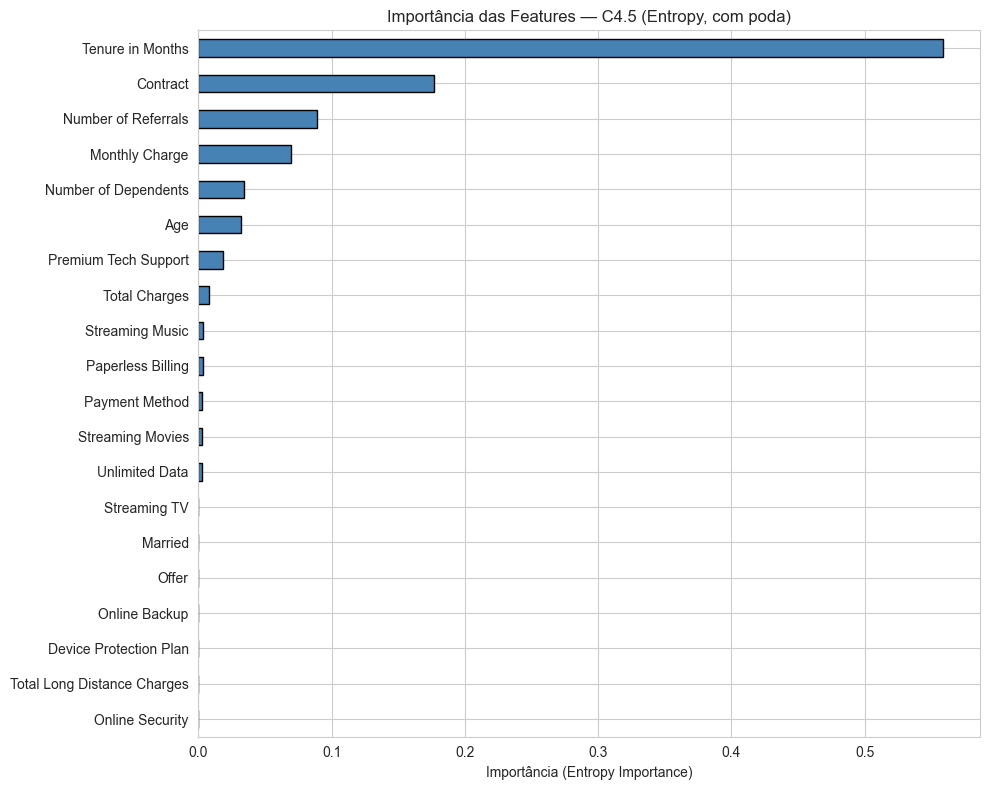

Top 5 features mais importantes:
  Tenure in Months: 0.5587
  Contract: 0.1769
  Number of Referrals: 0.0887
  Monthly Charge: 0.0693
  Number of Dependents: 0.0341


In [97]:
# Feature importances do melhor modelo (C4.5 podado)
importances = tree_c45.feature_importances_
feat_imp = pd.Series(importances, index=selected_features).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Importância (Entropy Importance)')
plt.title('Importância das Features — C4.5 (Entropy, com poda)')
plt.tight_layout()
plt.show()

print("Top 5 features mais importantes:")
for feat, imp in feat_imp.sort_values(ascending=False).head(5).items():
    print(f"  {feat}: {imp:.4f}")


## 10.2 Regras de decisão extraídas

In [98]:
# Regras da árvore podada
rules = export_text(tree_c45, feature_names=selected_features, class_names=list(le_target.classes_), max_depth=5)
print(rules)

|--- Tenure in Months <= 3.50
|   |--- Premium Tech Support <= 0.50
|   |   |--- Contract <= 0.50
|   |   |   |--- Age <= 63.50
|   |   |   |   |--- Number of Referrals <= 4.50
|   |   |   |   |   |--- Monthly Charge <= 64.25
|   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |   |--- Monthly Charge >  64.25
|   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- Number of Referrals >  4.50
|   |   |   |   |   |--- class: Joined
|   |   |   |--- Age >  63.50
|   |   |   |   |--- class: Churned
|   |   |--- Contract >  0.50
|   |   |   |--- class: Joined
|   |--- Premium Tech Support >  0.50
|   |   |--- Monthly Charge <= 75.95
|   |   |   |--- Payment Method <= 1.50
|   |   |   |   |--- Total Charges <= 60.33
|   |   |   |   |   |--- Paperless Billing <= 0.50
|   |   |   |   |   |   |--- class: Joined
|   |   |   |   |   |--- Paperless Billing >  0.50
|   |   |   |   |   |   |--- class: Churned
|   |   |   |   |--- Total Charges >  60.33
|   

## 10.3 Limiares de divisão para atributos contínuos

O scikit-learn trata atributos contínuos testando todos os pontos médios entre valores consecutivos ordenados e escolhendo o limiar que maximiza o ganho de informação (critério `entropy`). Esse comportamento é equivalente ao C4.5 para atributos contínuos.

Por exemplo, se o atributo `Tenure in Months` tem valores [1, 5, 9, 13, ...], o algoritmo testa limiares como 3.0, 7.0, 11.0, etc. e seleciona aquele que produz o maior ganho de informação.

Na árvore visualizada, cada nó de decisão mostra a condição (ex: `Tenure in Months <= 6.5`), o que permite interpretar diretamente os pontos de corte escolhidos pelo algoritmo.


## 10.4 Conclusão da interpretação

Baseado na árvore de decisão gerada, podemos identificar os principais fatores que influenciam o churn dos clientes de telecomunicações. Os atributos mais próximos da raiz são os mais discriminativos para a classificação, e as regras extraídas oferecem insights acionáveis para a retenção de clientes.